# Figure 1 — Data Landscape

**Claim**: the study integrates climate, urban morphology, vegetation, population and mobility
across 12 climatically diverse Spanish cities.

Panels: A) 12-city map by climate region, B) Palma network + Building Block Height,
C) Palma canopy source categorical map (WorldCover/STL/spatial union — see thermal.canopy_fusion),
D) population (MITMA district-level) — vulnerability index BLOCKED (never computed, see audit).

No simulation/download/canopy/building-shadow recomputation. Read-only, light analysis only.


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from plotting_utils import (set_nature_style, new_panel_fig, label_panel, save_panel,
                              save_source_table, blocked_panel, make_composite,
                              CLIMATE_COLORS, CLIMATE_REGION_LABELS, SEED)
np.random.seed(SEED)
set_nature_style()
# Bigger text for this figure's panels (local override -- other figures keep
# the shared plotting_utils defaults unless they opt in the same way).
matplotlib.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

FIG_DIR = REPO_ROOT / "figures" / "paper" / "main" / "figure1"
TAB_DIR = REPO_ROOT / "reports" / "paper_figures" / "figure1"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT =", REPO_ROOT)


REPO_ROOT = /home/fbellisardi/code/green_mobility


## Audit

In [2]:

from green_mobility.config import load_all_cities, CONFIGS_DIR
cities = load_all_cities(CONFIGS_DIR / "cities")
print(f"n cities configured: {len(cities)}")
for slug, c in sorted(cities.items()):
    print(f"  {slug}: lat={c.lat}, lon={c.lon}")

pop_path = REPO_ROOT / "data" / "vulnerability" / "city_population_mitma.parquet"
pop_available = pop_path.exists()
print(f"\npopulation (MITMA) available: {pop_available}")

canopy_v2_path = REPO_ROOT / "data" / "palma_de_mallorca" / "green_mobility" / "thermal" / "canopy_fraction_v2.parquet"
print(f"canopy_v2 (Palma) available: {canopy_v2_path.exists()}")

nodes_path = REPO_ROOT / "data" / "palma_de_mallorca" / "nodes.parquet"
bbh_candidates = list((REPO_ROOT / "data" / "climate_raw" / "urban_atlas" / "bbh").glob("*PALMA*.tif"))
print(f"Palma network available: {nodes_path.exists()}")
print(f"Palma BBH raster available: {len(bbh_candidates) > 0}")

vulnerability_index_path = REPO_ROOT / "data"
vuln_files = list((REPO_ROOT / "data").glob("*/vulnerability/*.parquet"))
print(f"\nvulnerability index files found: {len(vuln_files)} -- {'BLOCKED (never computed)' if len(vuln_files)==0 else vuln_files}")


fua_path = REPO_ROOT / "data" / "fua" / "boundaries.gpkg"
fua_available = fua_path.exists()
print(f"\nFUA boundaries file available: {fua_available}")
palma_fua_bounds = None
if fua_available:
    import geopandas as gpd
    fuas = gpd.read_file(fua_path, layer="FUAs")
    palma_fua = fuas[fuas["fuaname"] == "Palma de Mallorca"]
    if len(palma_fua) == 1:
        palma_fua_bounds = tuple(palma_fua.total_bounds)  # (minx, miny, maxx, maxy), EPSG:4326
        print(f"Palma FUA matched, bounds (lon/lat) = {palma_fua_bounds}")
    else:
        print(f"Palma FUA NOT matched by exact name (found {len(palma_fua)} rows) -- panels B/C will fall back to BLOCKED for the FUA extent")


n cities configured: 12
  a_coruna: lat=43.3623, lon=-8.4115
  barcelona: lat=41.3874, lon=2.1686
  bilbao: lat=43.263, lon=-2.935
  cordoba: lat=37.8789, lon=-4.7794
  granada: lat=37.1773, lon=-3.5986
  madrid: lat=40.4168, lon=-3.7038
  murcia: lat=37.9922, lon=-1.1307
  palma_de_mallorca: lat=39.5696, lon=2.6502
  sevilla: lat=37.3891, lon=-5.9845
  valencia: lat=39.4699, lon=-0.3763
  valladolid: lat=41.6523, lon=-4.7245
  zaragoza: lat=41.6488, lon=-0.8891

population (MITMA) available: True
canopy_v2 (Palma) available: True
Palma network available: True
Palma BBH raster available: True

vulnerability index files found: 0 -- BLOCKED (never computed)

FUA boundaries file available: True


Palma FUA matched, bounds (lon/lat) = (np.float64(2.3035999999999994), np.float64(39.124999999999986), np.float64(3.165999999999999), np.float64(39.83389999999997))


## Panel A — 12-city map

Climate classification: real per-city Köppen-Geiger codes (verified against each city's
Wikipedia climate section, itself sourced to AEMET/Köppen-Geiger -- see chat for the
per-city citation check done 2026-07-20). This replaces an earlier custom 5-bucket
descriptive scheme that mixed a Köppen axis with an elevation axis and mis-grouped
Sevilla/Córdoba (officially Csa, Mediterranean) as semi-arid alongside Murcia (BSh).
Marker size = FUA population (MITMA district-level estimate, see reports/thermal/dose_benefit_analysis_v2
audit) -- an approximation, not a validated census figure.

In [3]:
CITY_CLIMATE_REGION = {
    # Real per-city Köppen-Geiger codes (verified against Wikipedia climate
    # sections / AEMET, not a downloaded dataset but a checked external
    # classification -- see plotting_utils.CLIMATE_COLORS / CLIMATE_REGION_LABELS
    # for the code->color/label map).
    "palma_de_mallorca": "BSh",   # hot semi-arid, bordering Csa
    "barcelona": "Csa",
    "valencia": "BSh",            # hot semi-arid, bordering Csa
    "murcia": "BSh",
    "sevilla": "Csa",
    "cordoba": "Csa",
    "zaragoza": "BSk",            # cold semi-arid
    "valladolid": "Csa",          # Csa with BSk influence; Csa is the primary code cited
    "madrid": "BSk",              # cold semi-arid, transitioning to Csa in the west
    "granada": "Csa",             # close to BSk; elevation 738m not itself a Köppen axis
    "bilbao": "Cfb",              # oceanic
    "a_coruna": "Csb",            # warm-summer Mediterranean/oceanic-transitional
}

city_names = {
    "palma_de_mallorca": "Palma", "zaragoza": "Zaragoza", "murcia": "Murcia",
    "valladolid": "Valladolid", "madrid": "Madrid", "barcelona": "Barcelona",
    "valencia": "Valencia", "sevilla": "Sevilla", "cordoba": "C\u00f3rdoba",
    "granada": "Granada", "bilbao": "Bilbao", "a_coruna": "A Coru\u00f1a",
}

pop_df = pd.read_parquet(pop_path) if pop_available else None

rows = []
for slug, c in cities.items():
    row = {"city": slug, "name": city_names.get(slug, slug), "lat": c.lat, "lon": c.lon,
           "climate_region": CITY_CLIMATE_REGION.get(slug, "unknown")}
    if pop_available and slug in set(pop_df["city"]):
        row["population_fua"] = float(pop_df[pop_df["city"] == slug]["population"].iloc[0])
    else:
        row["population_fua"] = np.nan
    rows.append(row)
panel_a_df = pd.DataFrame(rows).sort_values("name")
save_source_table(panel_a_df, TAB_DIR, "panel_a")
print(panel_a_df.to_string(index=False))


             city       name     lat     lon climate_region  population_fua
         a_coruna   A Coruña 43.3623 -8.4115            Csb        507007.0
        barcelona  Barcelona 41.3874  2.1686            Csa             NaN
           bilbao     Bilbao 43.2630 -2.9350            Cfb       1137705.0
          cordoba    Córdoba 37.8789 -4.7794            Csa        464405.0
          granada    Granada 37.1773 -3.5986            Csa        632973.0
           madrid     Madrid 40.4168 -3.7038            BSk       7244184.0
           murcia     Murcia 37.9922 -1.1307            BSh        890538.0
palma_de_mallorca      Palma 39.5696  2.6502            BSh        796221.0
          sevilla    Sevilla 37.3891 -5.9845            Csa       1692723.0
         valencia   Valencia 39.4699 -0.3763            BSh       1965825.0
       valladolid Valladolid 41.6523 -4.7245            Csa        472505.0
         zaragoza   Zaragoza 41.6488 -0.8891            BSk        827238.0


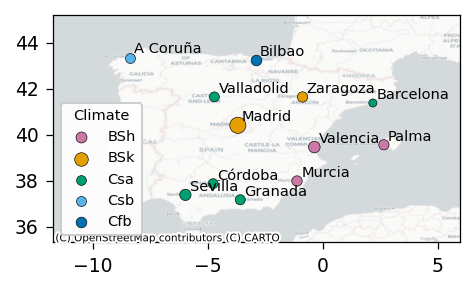

In [44]:

import contextily as ctx

fig, ax = new_panel_fig(3.5, 4.2)
for region, color in CLIMATE_COLORS.items():
    sub = panel_a_df[panel_a_df["climate_region"] == region]
    if len(sub) == 0:
        continue
    sizes = (20 + 40 * (sub["population_fua"] / panel_a_df["population_fua"].max())).fillna(15) if pop_available else 30
    ax.scatter(sub["lon"], sub["lat"], s=sizes, color=color, label=region,
               edgecolor="black", linewidth=0.3, zorder=3)
for _, r in panel_a_df.iterrows():
    ax.annotate(r["name"], (r["lon"], r["lat"]), fontsize=7, xytext=(2, 2), textcoords="offset points", zorder=4)
# ax.set_xlabel("Lon", fontsize=10); ax.set_ylabel("Lat", fontsize=10)
ax.tick_params(labelsize=9)
ax.set_aspect("equal")
# pad the frame a bit before fetching tiles, so markers/labels aren't flush with the edge
lon_pad = 0.3 * (panel_a_df["lon"].max() - panel_a_df["lon"].min())
lat_pad = 0.3 * (panel_a_df["lat"].max() - panel_a_df["lat"].min())
ax.set_xlim(panel_a_df["lon"].min() - lon_pad, panel_a_df["lon"].max() + lon_pad)
ax.set_ylim(panel_a_df["lat"].min() - lat_pad, panel_a_df["lat"].max() + lat_pad)
try:
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zorder=0, attribution_size=5)
except Exception as exc:
    # basemap tiles need network access; if unavailable, keep the plain axes rather than fail the panel
    print(f"contextily basemap unavailable ({exc}), continuing without it")
ax.legend(fontsize=7, loc="lower left", framealpha=0.95, title="Climate", title_fontsize=7)
# label_panel(ax, "A", fontsize=14)
save_panel(fig, FIG_DIR, "panel_a")
plt.show()


## Panel B — Buildings and trees, zoomed on Palma's urban core

Two sub-panels at the same zoom (real urban-core box, not the whole FUA -- at FUA
scale <1.1% of pixels are actual building pixels, so buildings/canopy detail is
invisible): building heights (BBH) and tree canopy (fused spatial union,
`canopy_fraction_v2.parquet`, 15m buffer).

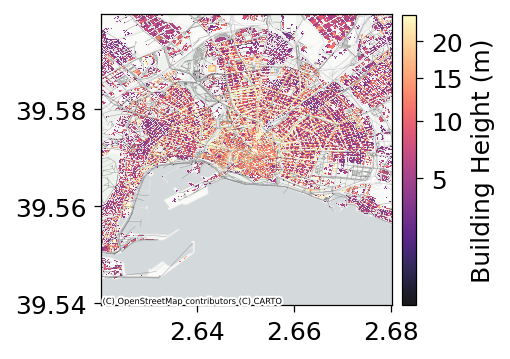

/home/fbellisardi/code/green_mobility/figures/paper/main/figure1


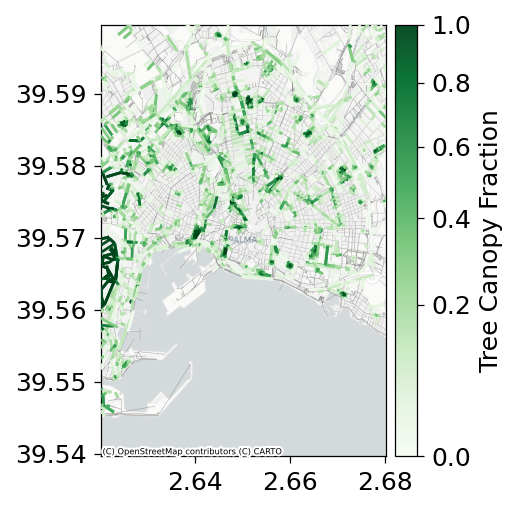

In [46]:
panel_b_ready = (nodes_path.exists() and len(bbh_candidates) > 0
                  and canopy_v2_path.exists() and palma_fua_bounds is not None)
if panel_b_ready:
    import rasterio
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from matplotlib.collections import LineCollection
    import contextily as ctx
    from matplotlib.colors import PowerNorm, LinearSegmentedColormap

    nodes = pd.read_parquet(REPO_ROOT / "data" / "palma_de_mallorca" / "nodes.parquet")
    edges = pd.read_parquet(REPO_ROOT / "data" / "palma_de_mallorca" / "edges.parquet")
    n_lon = nodes.set_index("node_id")["lon"]; n_lat = nodes.set_index("node_id")["lat"]

    lon_c, lat_c, pad = 2.6502, 39.5696, 0.03
    zminx, zmaxx, zminy, zmaxy = lon_c - pad, lon_c + pad, lat_c - pad, lat_c + pad
    PANEL_B_SIZE = (3.5, 3.5)  # same figsize for both -- so they compose/align identically

    sub_edges = edges[(n_lon.reindex(edges["from_node"]).values > zminx) &
                       (n_lon.reindex(edges["from_node"]).values < zmaxx) &
                       (n_lat.reindex(edges["from_node"]).values > zminy) &
                       (n_lat.reindex(edges["from_node"]).values < zmaxy)]
    edge_segments = np.stack([
        np.column_stack([n_lon.reindex(sub_edges["from_node"]).values, n_lat.reindex(sub_edges["from_node"]).values]),
        np.column_stack([n_lon.reindex(sub_edges["to_node"]).values, n_lat.reindex(sub_edges["to_node"]).values]),
    ], axis=1)

    # --- B1: building heights (BBH), zoomed -- its own standalone figure ---
    fig_b, ax_b = new_panel_fig(*PANEL_B_SIZE)
    ax_b.set_xlim(zminx, zmaxx); ax_b.set_ylim(zminy, zmaxy)
    try:
        ctx.add_basemap(ax_b, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zorder=0, attribution_size=4)
    except Exception as exc:
        print(f"contextily basemap unavailable ({exc}), continuing without it")
    ax_b.add_collection(LineCollection(edge_segments, colors="#666666", linewidths=0.2, zorder=2, alpha=0.35))
    # ax_b.set_xlabel("Lon", fontsize=9); ax_b.set_ylabel("latitude", fontsize=9)
    ax_b.tick_params(labelsize=12)
    
    base_cmap = plt.colormaps["Reds"]
    cmap_buildings = LinearSegmentedColormap.from_list(
        "Reds_truncated",
        base_cmap(np.linspace(0.25, 1.0, 256))
    )

    with rasterio.open(bbh_candidates[0]) as src:
        dst_crs = "EPSG:4326"
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        band = np.full((height, width), np.nan, dtype="float32")
        reproject(
            source=rasterio.band(src, 1), destination=band,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=transform, dst_crs=dst_crs,
            src_nodata=src.nodata, dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )
        left, top = transform * (0, 0)
        right, bottom = transform * (width, height)
        extent = [left, right, bottom, top]
        band_plot = np.ma.masked_where(~np.isfinite(band) | (band <= 0), band,)
        vmax_b = np.nanpercentile(band[band > 0], 98)
        norm_b = PowerNorm( gamma=0.50, vmin=0.5, vmax=vmax_b,)
        im_b = ax_b.imshow(band_plot, extent=extent,cmap="magma" ,norm=norm_b,interpolation="nearest",alpha=0.90, zorder=1, origin="upper",)
        
    cbar_b = plt.colorbar(im_b, ax=ax_b, fraction=0.046, pad=0.03)
    cbar_b.set_label("Building Height (m)", fontsize=12)
    cbar_b.ax.tick_params(labelsize=12)
    # label_panel(ax_b, "B", fontsize=14)
    # ax_b.set_title("Buildings", fontsize=9)
    fig_b.tight_layout()
    save_panel(fig_b, FIG_DIR, "panel_b_buildings")
    plt.show()

    # --- B2: tree canopy (fused spatial union, continuous fraction), same
    # zoom and same figsize -- its own standalone figure ---
    canopy_v2 = pd.read_parquet(canopy_v2_path)
    canopy_15 = canopy_v2[canopy_v2["buffer_m"] == 15.0]
    merged = edges.merge(canopy_15, on="edge_id", how="inner")
    merged["from_lon"] = n_lon.reindex(merged["from_node"]).values
    merged["from_lat"] = n_lat.reindex(merged["from_node"]).values
    merged["to_lon"] = n_lon.reindex(merged["to_node"]).values
    merged["to_lat"] = n_lat.reindex(merged["to_node"]).values
    tree_sub = merged[(merged["from_lon"] > zminx) & (merged["from_lon"] < zmaxx) &
                       (merged["from_lat"] > zminy) & (merged["from_lat"] < zmaxy)]
    tree_segments = np.stack([
        np.column_stack([tree_sub["from_lon"].values, tree_sub["from_lat"].values]),
        np.column_stack([tree_sub["to_lon"].values, tree_sub["to_lat"].values]),
    ], axis=1)

    fig_t, ax_t = new_panel_fig(*PANEL_B_SIZE)
    ax_t.set_xlim(zminx, zmaxx); ax_t.set_ylim(zminy, zmaxy)
    try:
        ctx.add_basemap(ax_t, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zorder=0, attribution_size=4)
    except Exception as exc:
        print(f"contextily basemap unavailable ({exc}), continuing without it")
    ax_t.add_collection(LineCollection(edge_segments, colors="#666666", linewidths=0.2, zorder=2, alpha=0.35))
    # ax_t.set_xlabel("longitude", fontsize=9); ax_t.set_ylabel("latitude", fontsize=9)
    ax_t.tick_params(labelsize=12)

    canopy_values = tree_sub["fused_canopy_fraction"].to_numpy(dtype=float)
    valid_canopy = np.isfinite(canopy_values) & (canopy_values > 0)
    tree_segments_plot = tree_segments[valid_canopy]
    canopy_values_plot = canopy_values[valid_canopy]
    tree_norm = PowerNorm(
        gamma=0.65,  # < 1 enfatizza i valori bassi
        vmin=0,
        vmax=1,
    )

    tree_lc = LineCollection(
        tree_segments_plot,
        array=canopy_values_plot,
        cmap="Greens",
        norm=tree_norm,
        linewidths=1.35,
        zorder=3,
        alpha=0.95,
    )

    ax_t.add_collection(tree_lc)
    cbar_t = plt.colorbar(tree_lc, ax=ax_t, fraction=0.08, pad=0.03)
    cbar_t.set_label("Tree Canopy Fraction", fontsize=12)
    cbar_t.ax.tick_params(labelsize=12)
    # label_panel(ax_t, "B", fontsize=14)
    # ax_t.set_title("trees", fontsize=9)
    fig_t.tight_layout()
    save_panel(fig_t, FIG_DIR, "panel_b_trees")
    print(FIG_DIR)
    
    plt.show()

    assert fig_b.get_size_inches().tolist() == fig_t.get_size_inches().tolist() == list(PANEL_B_SIZE), \
        "panel_b_buildings and panel_b_trees must be saved at the same figure size"

    save_source_table(pd.DataFrame({
        "n_edges_shown": [len(sub_edges)], "n_tree_edges_shown": [len(tree_sub)],
        "extent": [f"Palma urban-core zoom, center=({lon_c},{lat_c}), pad={pad} deg"],
        "figsize_in": [PANEL_B_SIZE],
        "bbh_source": [bbh_candidates[0].name],
        "canopy_source": ["canopy_fraction_v2.parquet, fused_canopy_fraction, buffer_m=15"],
    }), TAB_DIR, "panel_b")
else:
    fig_b, ax_b = new_panel_fig(3.5, 3.5)
    missing = [str(nodes_path), "BBH raster (data/climate_raw/urban_atlas/bbh)", str(canopy_v2_path)]
    if palma_fua_bounds is None:
        missing.append(str(fua_path))
    blocked_panel(ax_b, "B", "Palma network, BBH raster, canopy_v2, or FUA boundary not found", missing)
    save_panel(fig_b, FIG_DIR, "panel_b_buildings")
    fig_t, ax_t = new_panel_fig(3.5, 3.5)
    blocked_panel(ax_t, "B", "Palma network, BBH raster, canopy_v2, or FUA boundary not found", missing)
    save_panel(fig_t, FIG_DIR, "panel_b_trees")
    plt.show()


## Panel C — Canopy source categorical map (WorldCover/STL/spatial union)

Uses `source_flags` already computed in `canopy_fraction_v2.parquet` (Phase-1-validated spatial union, not the probabilistic formula).

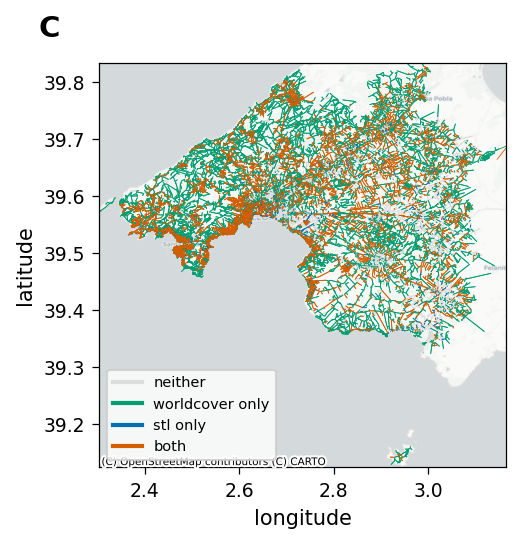

source_flags
neither            81237
worldcover_only    62404
both               36695
stl_only            6074
Name: count, dtype: int64


In [6]:

panel_c_ready = canopy_v2_path.exists() and palma_fua_bounds is not None
if panel_c_ready:
    from matplotlib.collections import LineCollection
    import contextily as ctx

    canopy_v2 = pd.read_parquet(canopy_v2_path)
    canopy_15 = canopy_v2[canopy_v2["buffer_m"] == 15.0]
    edges = pd.read_parquet(REPO_ROOT / "data" / "palma_de_mallorca" / "edges.parquet")
    nodes = pd.read_parquet(REPO_ROOT / "data" / "palma_de_mallorca" / "nodes.parquet")
    n_lon = nodes.set_index("node_id")["lon"]; n_lat = nodes.set_index("node_id")["lat"]
    merged = edges.merge(canopy_15, on="edge_id", how="inner")

    # Palma FUA extent (same boundary as Panel B), not an arbitrary hand-picked box.
    minx, miny, maxx, maxy = palma_fua_bounds
    merged["from_lon"] = n_lon.reindex(merged["from_node"]).values
    merged["from_lat"] = n_lat.reindex(merged["from_node"]).values
    merged["to_lon"] = n_lon.reindex(merged["to_node"]).values
    merged["to_lat"] = n_lat.reindex(merged["to_node"]).values
    sub = merged[(merged["from_lon"] > minx) & (merged["from_lon"] < maxx) &
                 (merged["from_lat"] > miny) & (merged["from_lat"] < maxy)]

    cat_colors = {"neither": "#dddddd", "worldcover_only": "#009E73", "stl_only": "#0072B2", "both": "#D55E00"}
    fig, ax = new_panel_fig(3.5, 3.5)
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    try:
        ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zorder=0, attribution_size=5)
    except Exception as exc:
        print(f"contextily basemap unavailable ({exc}), continuing without it")
    for cat, color in cat_colors.items():
        cat_sub = sub[sub["source_flags"] == cat]
        if len(cat_sub) == 0:
            continue
        segments = np.stack([
            np.column_stack([cat_sub["from_lon"].values, cat_sub["from_lat"].values]),
            np.column_stack([cat_sub["to_lon"].values, cat_sub["to_lat"].values]),
        ], axis=1)
        ax.add_collection(LineCollection(segments, colors=color, linewidths=0.4, zorder=2))
    handles = [plt.Line2D([0], [0], color=c, lw=2, label=k.replace("_"," ")) for k, c in cat_colors.items()]
    ax.legend(handles=handles, fontsize=7, loc="lower left")
    ax.set_xlabel("longitude", fontsize=10); ax.set_ylabel("latitude", fontsize=10)
    ax.tick_params(labelsize=9)
    label_panel(ax, "C", fontsize=14)
    save_panel(fig, FIG_DIR, "panel_c")
    save_source_table(sub[["edge_id","source_flags","worldcover_canopy_fraction","street_tree_fraction","fused_canopy_fraction"]],
                       TAB_DIR, "panel_c")
    plt.show()
    print(sub["source_flags"].value_counts())
else:
    fig, ax = new_panel_fig(3.5, 3.5)
    missing = [str(canopy_v2_path)]
    if palma_fua_bounds is None:
        missing.append(str(fua_path))
    blocked_panel(ax, "C", "canopy_fraction_v2.parquet or FUA boundary not found for Palma", missing)
    save_panel(fig, FIG_DIR, "panel_c")
    plt.show()


## Panel D — Population and vulnerability

Population: READY (MITMA). Income/poverty/Gini: only 4/11 cities. Vulnerability index: BLOCKED (never computed, see audit).

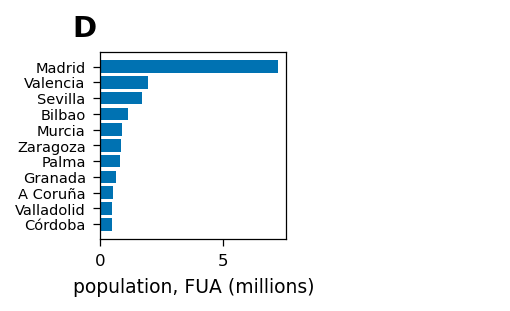

In [7]:

if pop_available:
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.2))
    plot_df = panel_a_df.dropna(subset=["population_fua"]).sort_values("population_fua", ascending=True)
    axes[0].barh(plot_df["name"], plot_df["population_fua"]/1e6, color="#0072B2")
    axes[0].set_xlabel("population, FUA (millions)", fontsize=9)
    axes[0].tick_params(axis='y', labelsize=7)
    axes[0].tick_params(axis='x', labelsize=8)
    label_panel(axes[0], "D", fontsize=14)
    axes[1].axis("off")
    # axes[1].text(0.5, 0.5, "Vulnerability index:\nBLOCKED\n(never computed --\nincome/poverty only\n4/11 cities, no\ncomposite index built)",
    #              ha="center", va="center", fontsize=8, transform=axes[1].transAxes,
    #              bbox=dict(boxstyle="round", facecolor="#f5f5f5", edgecolor="firebrick"))
    fig.tight_layout()
    save_panel(fig, FIG_DIR, "panel_d")
    save_source_table(plot_df[["city","name","population_fua"]], TAB_DIR, "panel_d")
    plt.show()
else:
    fig, ax = new_panel_fig(3.5, 3.5)
    blocked_panel(ax, "D", "population data not available", [str(pop_path)])
    save_panel(fig, FIG_DIR, "panel_d")
    plt.show()


## Composite preview

In [8]:
make_composite([FIG_DIR/"panel_a.png", FIG_DIR/"panel_b_buildings.png", FIG_DIR/"panel_b_trees.png",
                FIG_DIR/"panel_c.png", FIG_DIR/"panel_d.png"],
               FIG_DIR, "figure1")

manifest = {
    "figure": "figure1_data_landscape",
    "panel_a": {"status": "READY", "note": "climate region = reference classification, not a downloaded dataset"},
    "panel_b_buildings": {"status": "READY" if panel_b_ready else "BLOCKED", "note": "Palma urban-core zoom, not the whole FUA"},
    "panel_b_trees": {"status": "READY" if panel_b_ready else "BLOCKED", "note": "same zoom/figsize as panel_b_buildings"},
    "panel_c": {"status": "READY" if panel_c_ready else "BLOCKED"},
    "panel_d": {"status": "PARTIAL", "note": "population READY, vulnerability index BLOCKED (never computed)"},
}
(TAB_DIR / "manifest.json").write_text(__import__("json").dumps(manifest, indent=2))
print(manifest)


{'figure': 'figure1_data_landscape', 'panel_a': {'status': 'READY', 'note': 'climate region = reference classification, not a downloaded dataset'}, 'panel_b_buildings': {'status': 'READY', 'note': 'Palma urban-core zoom, not the whole FUA'}, 'panel_b_trees': {'status': 'READY', 'note': 'same zoom/figsize as panel_b_buildings'}, 'panel_c': {'status': 'READY'}, 'panel_d': {'status': 'PARTIAL', 'note': 'population READY, vulnerability index BLOCKED (never computed)'}}
